In [396]:
import cv2
import numpy as np
import os
import os.path
from tqdm import tqdm
from colorthief import ColorThief
from scipy import spatial
from ellipse import LsqEllipse
from matplotlib.patches import Ellipse
import matplotlib.pyplot as plt
%matplotlib inline 
from matplotlib import rc
rc('font',**{'family':'serif','serif':['Palatino']})
plt.rcParams['figure.dpi'] = 120

In [2]:
train1 = '/Users/imran/Downloads/planets/jupiter-training'
train2 = '/Users/imran/Downloads/planets/saturn-training'

test1 = '/Users/imran/Downloads/planets/jupiter-testing'
test2 = '/Users/imran/Downloads/planets/saturn-testing'

# Data set initial processing

In [25]:
jdir = '/Users/imran/Downloads/planets/jupiter'
sdir = '/Users/imran/Downloads/planets/saturn'
odir_j = '/Users/imran/Downloads/planets/jupiter2'
odir_s = '/Users/imran/Downloads/planets/saturn2'

In [ ]:
def centerim(fdir, f, odir, of):
    # https://stackoverflow.com/a/60050200
    # Load image, convert to grayscale, Gaussian blur, Otsu's threshold
    image = cv2.imread(os.path.join(fdir, f))
    original = image.copy()
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (3,3), 0)
    thresh = ~( cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1] )

    # Obtain bounding rectangle and extract ROI
    x,y,w,h = cv2.boundingRect(thresh)
    cv2.rectangle(image, (x, y), (x + w, y + h), (36,255,12), 2)
    ROI = original[y:y+h, x:x+w]

    # Add alpha channel
#     b,g,r = cv2.split(ROI)
#     alpha = np.ones(b.shape, dtype=b.dtype) * 50
#     ROI = cv2.merge([b,g,r,alpha])

    cv2.imwrite(os.path.join(odir, of), ROI)

In [23]:
for i,f in enumerate(os.listdir(sdir)):
    centerim(sdir, f, odir_s, f'{str(i).zfill(3)}.png')
for i,f in enumerate(os.listdir(jdir)):
    centerim(jdir, f, odir_j, f'{str(i).zfill(3)}.png')

# n color

In [3]:
def onecolor(fdir):
    res = []
    for f in tqdm(os.listdir(fdir)):
        color_thief = ColorThief(os.path.join(fdir,f))
        # get the dominant color
        dominant_color = color_thief.get_color(quality=1)
        res.append(dominant_color)
    return np.array(res).T

In [4]:
def ncolor(fdir, n=5):
    if n==1:
        return onecolor(fdir)
    res = []
    for f in tqdm(os.listdir(fdir)):
        color_thief = ColorThief(os.path.join(fdir,f))
        # get the dominant color
        dominant_color = color_thief.get_palette(quality=1, color_count=n)
        res.append(np.ravel(dominant_color))
    return np.array(res).T

In [5]:
rgb1dict = {}
rgb2dict = {}
for n in range(1,11):
    rgb1 = ncolor(train1, n)
    rgb2 = ncolor(train2, n)
    rgb1dict[n] = rgb1
    rgb2dict[n] = rgb2

100%|██████████| 85/85 [00:15<00:00,  5.49it/s]


In [6]:
rgb1dict_testing = {}
rgb2dict_testing = {}
for n in range(1,11):
    rgb1 = ncolor(test1, n)
    rgb2 = ncolor(test2, n)
    rgb1dict_testing[n] = rgb1
    rgb2dict_testing[n] = rgb2

100%|██████████| 85/85 [00:14<00:00,  5.89it/s]


In [8]:
def tn(n):
    rgb1 = rgb1dict[n]
    rgb2 = rgb2dict[n]
    cov1 = np.cov(rgb1)
    cov2 = np.cov(rgb2)
    W = cov1 + cov2
    avec = np.linalg.inv(W).dot(np.mean(rgb2, 1) - np.mean(rgb1, 1))
    return avec.dot(rgb1), avec.dot(rgb2)

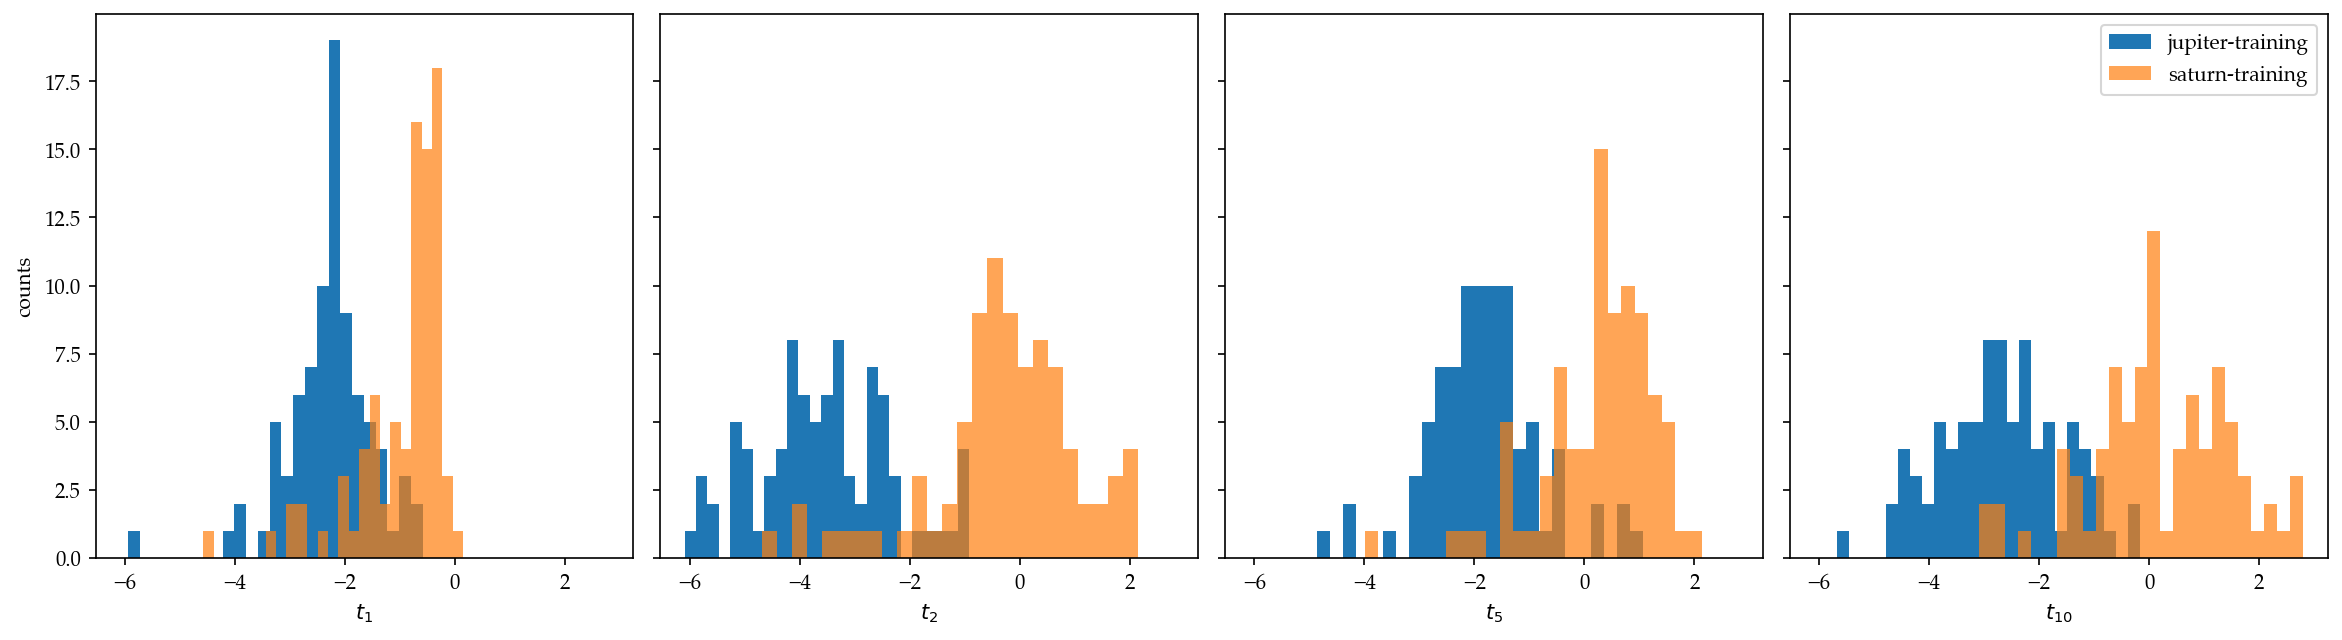

In [9]:
fig, axes = plt.subplots(1, 4, sharex=True, sharey='row', gridspec_kw={'wspace': .05, 'hspace':.03}, figsize=[4.8*4,4.8*1], dpi=150)

for i,n in enumerate([1,2,5,10]):
    axes[i].hist(tn(n)[0], bins=25, label='jupiter-training')
    axes[i].hist(tn(n)[1], bins=25, label='saturn-training', alpha=0.7)
    axes[i].set_xlabel(f'$t_{{{n}}}$')
axes[0].set_ylabel('counts')
axes[3].legend()
# plt.gca().minorticks_on()
plt.savefig('finalfigs/tn_dist.pdf')

In [10]:
def naccuracy(tc, n, avec):
    rgb1 = rgb1dict_testing[n]
    rgb2 = rgb2dict_testing[n]
    tA = avec.dot(rgb1)
    tB = avec.dot(rgb2)
    return (np.sum(tA<tc) + np.sum(tB>tc)) / (len(tA)+len(tB)) * 100

-1.64 0.225 72.4
-2.19 0.125 86.5
-1.21 0.184 85.3
-1.21 0.184 85.3
-0.92 0.166 80.0
-0.09 0.249 78.2
-0.11 0.269 78.2
-0.11 0.269 78.2
-0.73 0.235 79.4
-1.01 0.157 84.1


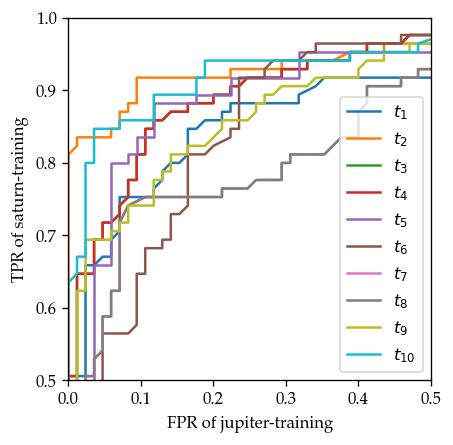

In [11]:
for n in sorted(rgb1dict.keys()):
    rgb1 = rgb1dict[n]
    rgb2 = rgb2dict[n]
    cov1 = np.cov(rgb1)
    cov2 = np.cov(rgb2)
    W = cov1 + cov2
    avec = np.linalg.inv(W).dot(np.mean(rgb2, 1) - np.mean(rgb1, 1))
    tA = avec.dot(rgb1)
    tB = avec.dot(rgb2)
    ROCt = np.array([ [np.sum(tA>tc)/len(tA), np.sum(tB>tc)/len(tB)] for tc in np.linspace(-5,5, 1000) ])
    plt.plot(ROCt[:,0], ROCt[:,1], label=f'$t_{{{n}}}$')
    
    amin = (ROCt[:,0]**2 + (ROCt[:,1]-1)**2).argmin()
    tc = np.linspace(-5,5, 1000)[amin]
    print(round(tc,2),round(np.sqrt((ROCt[:,0]**2 + (ROCt[:,1]-1)**2)).min(),3), round(naccuracy(tc, n, avec),1))

plt.legend()
plt.ylim(.5,1)
plt.xlim(0,.5)
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel('FPR of jupiter-training')
plt.ylabel('TPR of saturn-training')
plt.savefig('finalfigs/tn_ROC.pdf')

## Avg color palettes

In [62]:
def flatten(t):
    return [item for sublist in t for item in sublist]

In [90]:
x5_1 = np.array(flatten([np.split(r,5) for r in rgb1dict[5].T]))
x5_2 = np.array(flatten([np.split(r,5) for r in rgb2dict[5].T]))

In [119]:
cv2.imwrite('finalfigs/x5_1.png', np.array([x5_1])[:,:,::-1])
cv2.imwrite('finalfigs/x5_2.png', np.array([x5_2])[:,:,::-1])

True

In [129]:
color_thief = ColorThief('finalfigs/x5_1.png')
# get the dominant color
d1 = color_thief.get_palette(quality=1, color_count=5)

In [130]:
color_thief = ColorThief('finalfigs/x5_2.png')
# get the dominant color
d2 = color_thief.get_palette(quality=1, color_count=5)

In [126]:
from matplotlib import patches

In [145]:
d1 = np.array(d1)/255
d1 = np.array(d2)/255

# Shape classification

## steps plot

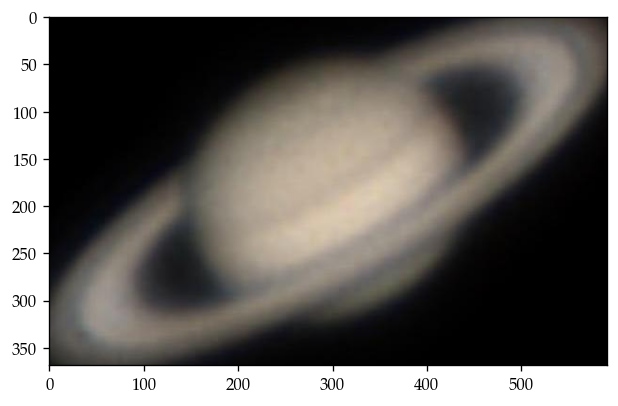

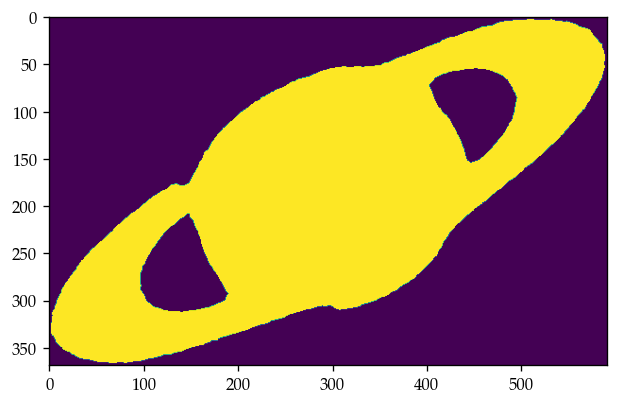

In [439]:
image = cv2.imread(os.path.join(train2, '017.png'))
plt.imshow(image[:,:,::-1])
plt.figure()
original = image.copy()
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (3,3), 0)
thresh = ~( cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1] )

# Obtain bounding rectangle and extract ROI
x,y,w,h = cv2.boundingRect(thresh)
cv2.rectangle(image, (x, y), (x + w, y + h), (36,255,12), 2)
ROI = original[y:y+h, x:x+w]

plt.imshow(thresh)

In [440]:
points = coords_from_mask(thresh)

In [441]:
hull = spatial.ConvexHull(points)

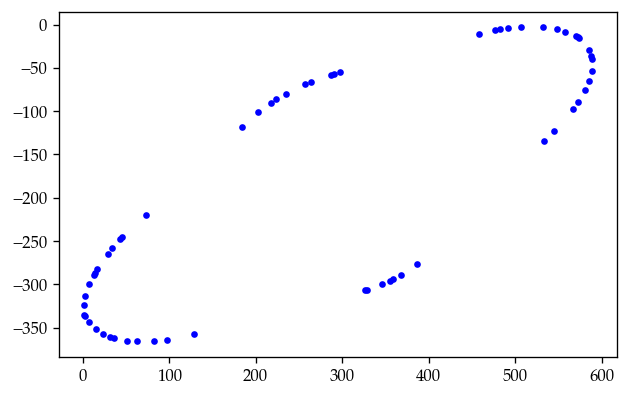

In [442]:
ex, ey = points[hull.vertices,0], points[hull.vertices,1]
# ex = ex - ex.mean()
# ey = ey - ey.mean()

plt.plot(ex, ey, 'b.', lw=2)
# plt.plot(points[hull.vertices[0],0], points[hull.vertices[0],1], 'ro')
plt.gca().set_aspect('equal', adjustable='box')

center: 296.685, -186.959
width: 320.227
height: 120.113
phi: 0.501


Text(500, -350, 'ellipse fit:\n$a=320.2$\n$b=120.1$\n$e=0.927$')

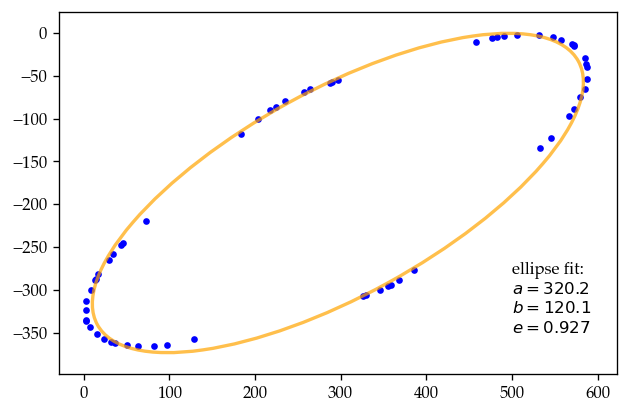

In [437]:
reg = LsqEllipse().fit(np.array([ex, ey]).T)
center, width, height, phi = reg.as_parameters()
center, width, height, phi = reg.as_parameters()

print(f'center: {center[0]:.3f}, {center[1]:.3f}')
print(f'width: {width:.3f}')
print(f'height: {height:.3f}')
print(f'phi: {phi:.3f}')

fig = plt.figure(figsize=(6, 6))
ax = plt.subplot()
ax.axis('equal')
ax.plot(ex, ey, 'b.', zorder=1)
ellipse = Ellipse(
    xy=center, width=2*width, height=2*height, angle=np.rad2deg(phi),
    edgecolor='orange', fc='None', lw=2, label='Fit', zorder=2, alpha=0.7
)
ax.add_patch(ellipse)
plt.gca().set_aspect('equal', adjustable='box')
e = np.sqrt(1-(height/width)**2)

plt.text(500, -350, f'ellipse fit:\n$a={round(width,1)}$\n$b={round(height,1)}$\n$e={round(e,3)}$')

## algorithm

In [451]:
def coords_from_mask(thresh):  
    x=[]
    y=[]
    for i in range(thresh.shape[0]):
        for j in range(thresh.shape[1]):
            if thresh[i,j]:
                x.append(j)
                y.append(i)
    y = np.array(y)*-1
    return np.array([x,y]).T

In [524]:
def calc_ecc(fdir, f, plotFlag=False):
    image = cv2.imread(os.path.join(fdir, f))
    if plotFlag:
        plt.imshow(image[:,:,::-1])
    original = image.copy()
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (3,3), 0)
    thresh = ~( cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1] )

    if plotFlag:
        plt.figure()
        plt.imshow(thresh)
    
    points = coords_from_mask(thresh)
    hull = spatial.ConvexHull(points)

    ex, ey = points[hull.vertices,0], points[hull.vertices,1]

    if plotFlag:
        plt.figure()
        plt.plot(ex, ey, 'b.', lw=2)
        plt.gca().set_aspect('equal', adjustable='box')

    reg = LsqEllipse().fit(np.array([ex, ey]).T)
    center, width, height, phi = reg.as_parameters()
    a_sm = np.max([height,width])
    b_sm = np.min([height,width])
    e = np.sqrt(1-(b_sm/a_sm)**2)
    if e < 0.1 and (not plotFlag):
        pass
#         calc_ecc(fdir, f, plotFlag=True)
   
    if plotFlag:
        print(f'center: {center[0]:.3f}, {center[1]:.3f}')
        print(f'width: {width:.3f}')
        print(f'height: {height:.3f}')
        print(f'phi: {phi:.3f}')

        fig = plt.figure(figsize=(6, 6))
        ax = plt.subplot()
        ax.axis('equal')
        ax.plot(ex, ey, 'b.', zorder=1)
        ellipse = Ellipse(
            xy=center, width=2*width, height=2*height, angle=np.rad2deg(phi),
            edgecolor='orange', fc='None', lw=2, label='Fit', zorder=2, alpha=0.7
        )
        ax.add_patch(ellipse)
#         plt.gca().set_aspect('equal', adjustable='box')


#         plt.text(500, -350, f'ellipse fit:\n$a={round(width,1)}$\n$b={round(height,1)}$\n$e={round(e,3)}$')
    return e

In [525]:
e1 = [calc_ecc(train1, f) for f in os.listdir(train1)]
e2 = [calc_ecc(train2, f) for f in os.listdir(train2)]

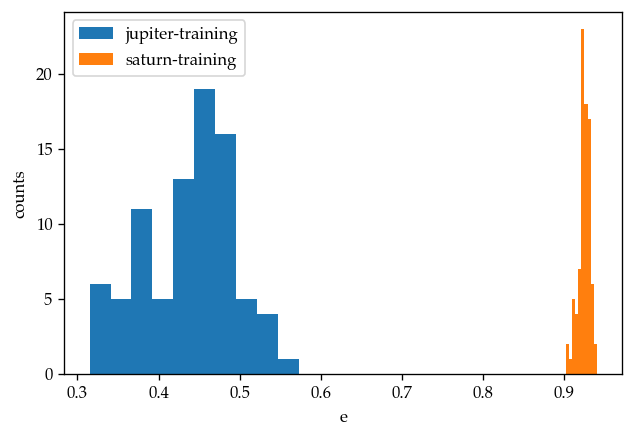

In [529]:
plt.hist(e1, label='jupiter-training')
plt.hist(e2, label='saturn-training')

plt.xlabel('e')
plt.ylabel('counts')
plt.legend()
plt.savefig('finalfigs/e_dist.pdf')

In [527]:
e1_test = np.array([calc_ecc(test1, f) for f in os.listdir(test1)])
e2_test = np.array([calc_ecc(test2, f) for f in os.listdir(test2)])

In [528]:
( np.sum(e1_test < 0.75) + np.sum(e2_test > 0.75) ) / (len(e1_test) + len(e2_test))

0.9941176470588236